In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [42]:
def phase_difference(x, y):
    # Calculate the analytic signal using the Hilbert transform
    analytic_x = signal.hilbert(x)
    analytic_y = signal.hilbert(y)
    
    # Calculate the instantaneous phase difference
    phase_diff = np.angle(analytic_y) - np.angle(analytic_x)
    
    # Wrap to [-pi, pi]
    return np.angle(np.exp(1j * phase_diff))


def rayleigh_stats(phase):
    # Calculate mean vector
    mean_x = np.mean(np.cos(phase))
    mean_y = np.mean(np.sin(phase))
    
    # Calculate mean resultant length and angle
    R = np.sqrt(mean_x**2 + mean_y**2)
    theta_mean = np.arctan2(mean_y, mean_x)
    
    return R, theta_mean


def plot_rayleigh(phase, R, theta_mean):
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
    
    # Plot data points (all with radius 1)
    ax.scatter(phase, np.ones_like(phase), alpha=0.5)
    
    # Plot mean vector
    ax.arrow(0, 0, theta_mean, R, alpha=0.8, width=0.02,
             edgecolor='red', facecolor='red', lw=2, zorder=5)
    
    # # Add circle for statistical significance (e.g., 0.05 level)
    # n = len(phase)
    # r_0 = np.sqrt(-np.log(0.05) * 2 / n)
    # circle = plt.Circle((0, 0), r_0, transform=ax.transData._b, 
    #                     fill=False, edgecolor='red', linestyle='--')
    # ax.add_artist(circle)
    
    ax.set_ylim(0, 1.1)  # Set radial limit
    ax.set_rticks([0.5, 1])  # Add some radial ticks
    ax.set_rlabel_position(-22.5)  # Move radial labels away from plotted line
    ax.grid(True)
    
    ax.set_title(f"R: {R:.4f}, Mean Phase Diff (degrees): {np.degrees(theta_mean):.2f}")
    plt.tight_layout()
    plt.show()

Mean resultant length (R): 0.9939
Mean phase difference (degrees): 135.08


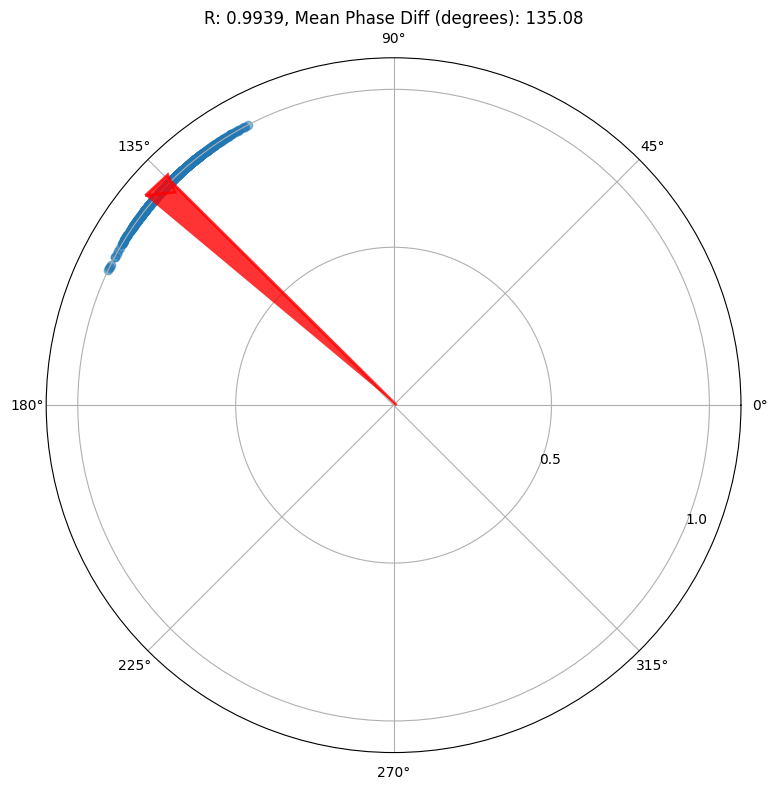

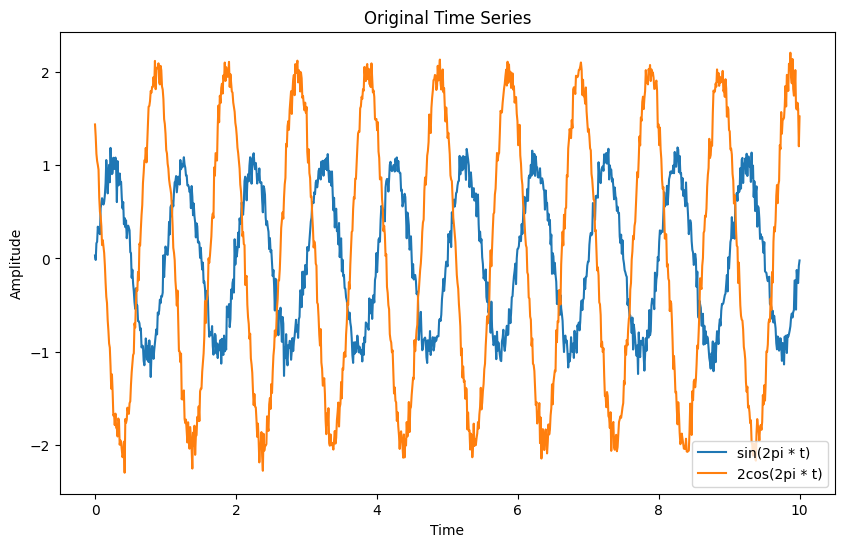

In [43]:
# Generate example time series
t = np.linspace(0, 10, 1000)
f1, f2 = 1, 1  # frequencies
phase_shift = np.pi/4  # phase shift between signals

x = np.sin(2 * np.pi * f1 * t)
y = 2 * np.cos(2 * np.pi * f2 * t + phase_shift)

# Add some noise
x += 0.1 * np.random.randn(len(t))
y += 0.1 * np.random.randn(len(t))

# Calculate phase differences
phase_diff = phase_difference(x, y)

# Calculate Rayleigh statistics
R, theta_mean = rayleigh_stats(phase_diff)

print(f"Mean resultant length (R): {R:.4f}")
print(f"Mean phase difference (degrees): {np.degrees(theta_mean):.2f}")

# Plot the results
plot_rayleigh(phase_diff, R, theta_mean)

# Plot the original time series
plt.figure(figsize=(10, 6))
plt.plot(t, x, label='sin(2pi * t)')
plt.plot(t, y, label='2cos(2pi * t)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Original Time Series')
plt.legend()
plt.show()

In [44]:
import os
source = "/Users/hades/Desktop/Bruchas Lab/Encoder_Decoder/DJM_binary_classification/Relate_Terminal_to_NAc/signal_data"
files = sorted([f for f in os.listdir(source) if f.endswith(".npy")])
full_paths = [os.path.join(source, f) for f in files]
np_arrs = [np.load(f) for f in full_paths]

In [45]:
nac1 = np_arrs[0]
nac2 = np_arrs[1]
nac3 = np_arrs[2]
nac4 = np_arrs[3]
nac5 = np_arrs[4]
terminal = np_arrs[5]

Mean resultant length (R): 0.9165
Mean phase difference (degrees): -26.30
Mean phase difference (milliseconds): 0.13


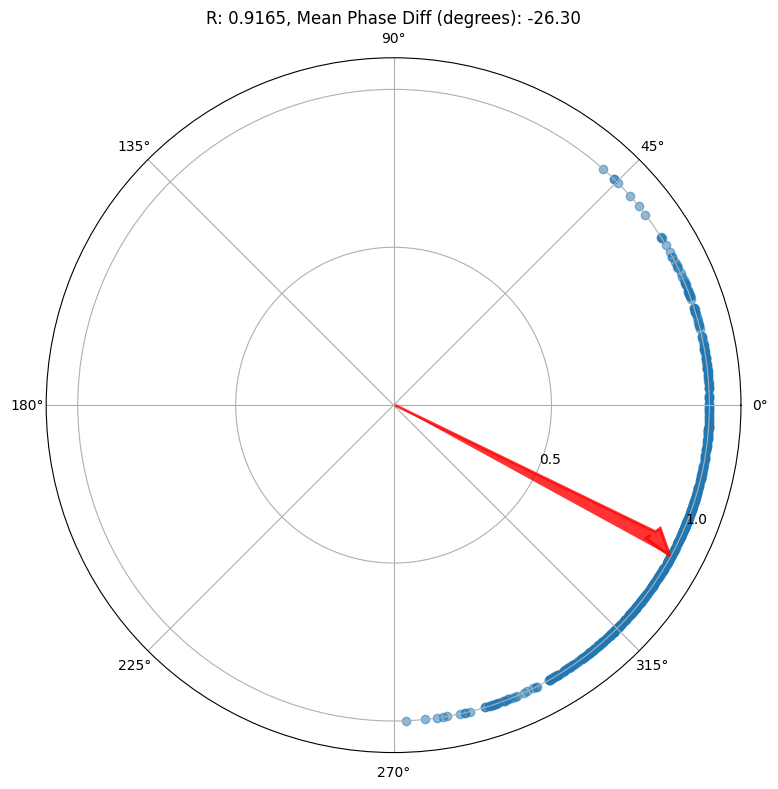

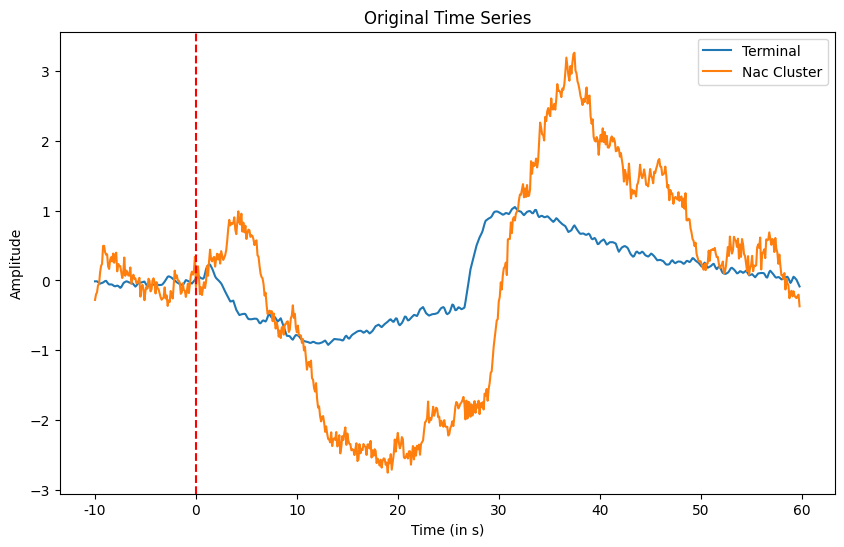

In [46]:
x = terminal
y = np.roll(nac5, 10)
t = np.arange(0, x.shape[0])

phase_diff = phase_difference(x, y)

# Calculate Rayleigh statistics
R, theta_mean = rayleigh_stats(phase_diff)

print(f"Mean resultant length (R): {R:.4f}")
print(f"Mean phase difference (degrees): {np.degrees(theta_mean):.2f}")

# Calculate time shift
sampling_rate = 700 / 71
period = 1 / sampling_rate
time_shift = (np.abs(theta_mean)/360) * period
print(f"Mean phase difference (milliseconds): {time_shift * 1e3:.2f}")

# Plot the results
plot_rayleigh(phase_diff, R, theta_mean)

# Plot the original time series
plt.figure(figsize=(10, 6))
plt.plot(t, x, label='Terminal')
plt.plot(t, y, label='Nac Cluster')
plt.axvline(x=100, color='r', linestyle='--')

ax = plt.gca()
def format_func(value, tick_number):
    return int(value/10) - 10

ax.xaxis.set_major_formatter(plt.FuncFormatter(format_func))


plt.xlabel('Time (in s)')
plt.ylabel('Amplitude')
plt.title('Original Time Series')
plt.legend()
plt.show()

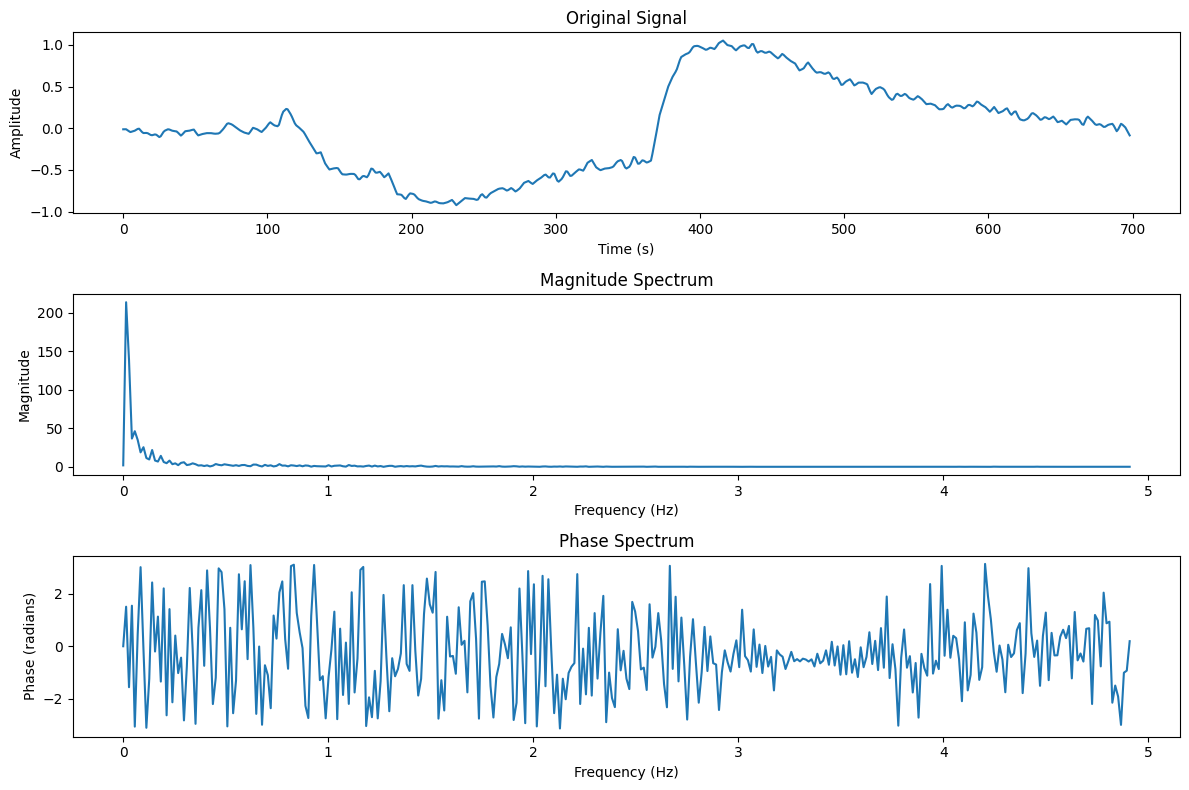

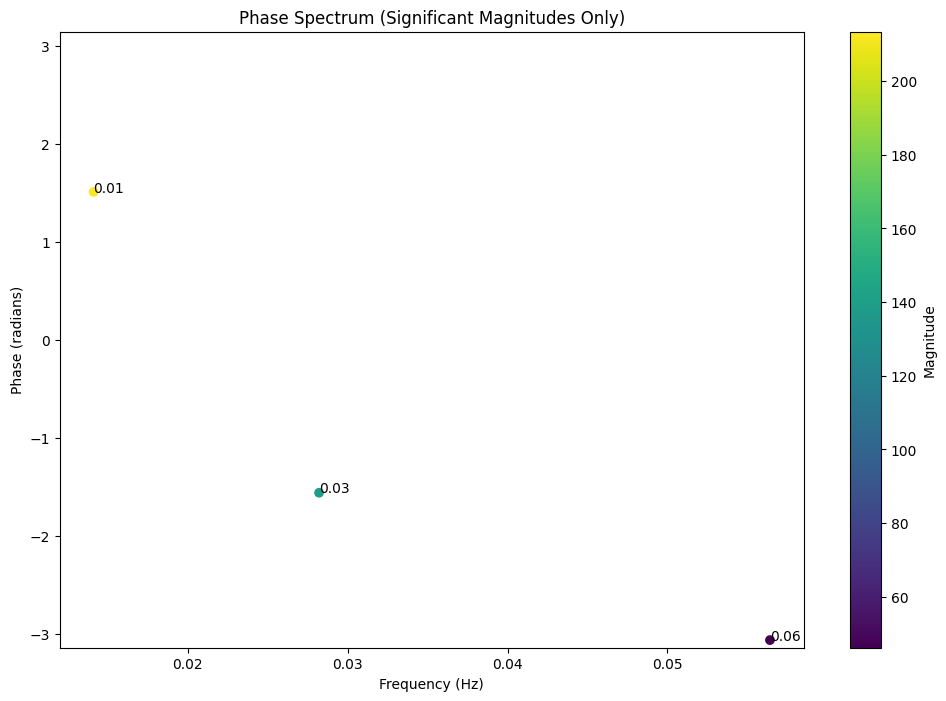

In [47]:
# Generate a sample signal
t = np.arange(0, 699)
signal = terminal

# Perform FFT
fft_result = np.fft.fft(signal)
frequencies = np.fft.fftfreq(len(t), 1/sampling_rate)

# Plot the original signal
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(t, signal)
plt.title('Original Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

# Plot the magnitude spectrum
plt.subplot(3, 1, 2)
plt.plot(frequencies[:len(frequencies)//2], np.abs(fft_result)[:len(frequencies)//2])
plt.title('Magnitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')

# Plot the phase spectrum
plt.subplot(3, 1, 3)
plt.plot(frequencies[:len(frequencies)//2], np.angle(fft_result)[:len(frequencies)//2])
plt.title('Phase Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase (radians)')

plt.tight_layout()
plt.show()

# Plot only for significant magnitudes
magnitude = np.abs(fft_result)
phase = np.angle(fft_result)
threshold = 0.20 * np.max(magnitude)
significant_freq = (magnitude > threshold) & (frequencies > 0)

plt.figure(figsize=(12, 8))
plt.scatter(frequencies[significant_freq], phase[significant_freq], c=magnitude[significant_freq], cmap='viridis')
for i_x, i_y in zip(frequencies[significant_freq], phase[significant_freq]):
    plt.text(i_x, i_y, f'{i_x:.2f}')
plt.colorbar(label='Magnitude')
plt.title('Phase Spectrum (Significant Magnitudes Only)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase (radians)')
plt.ylim(-np.pi, np.pi)
plt.show()

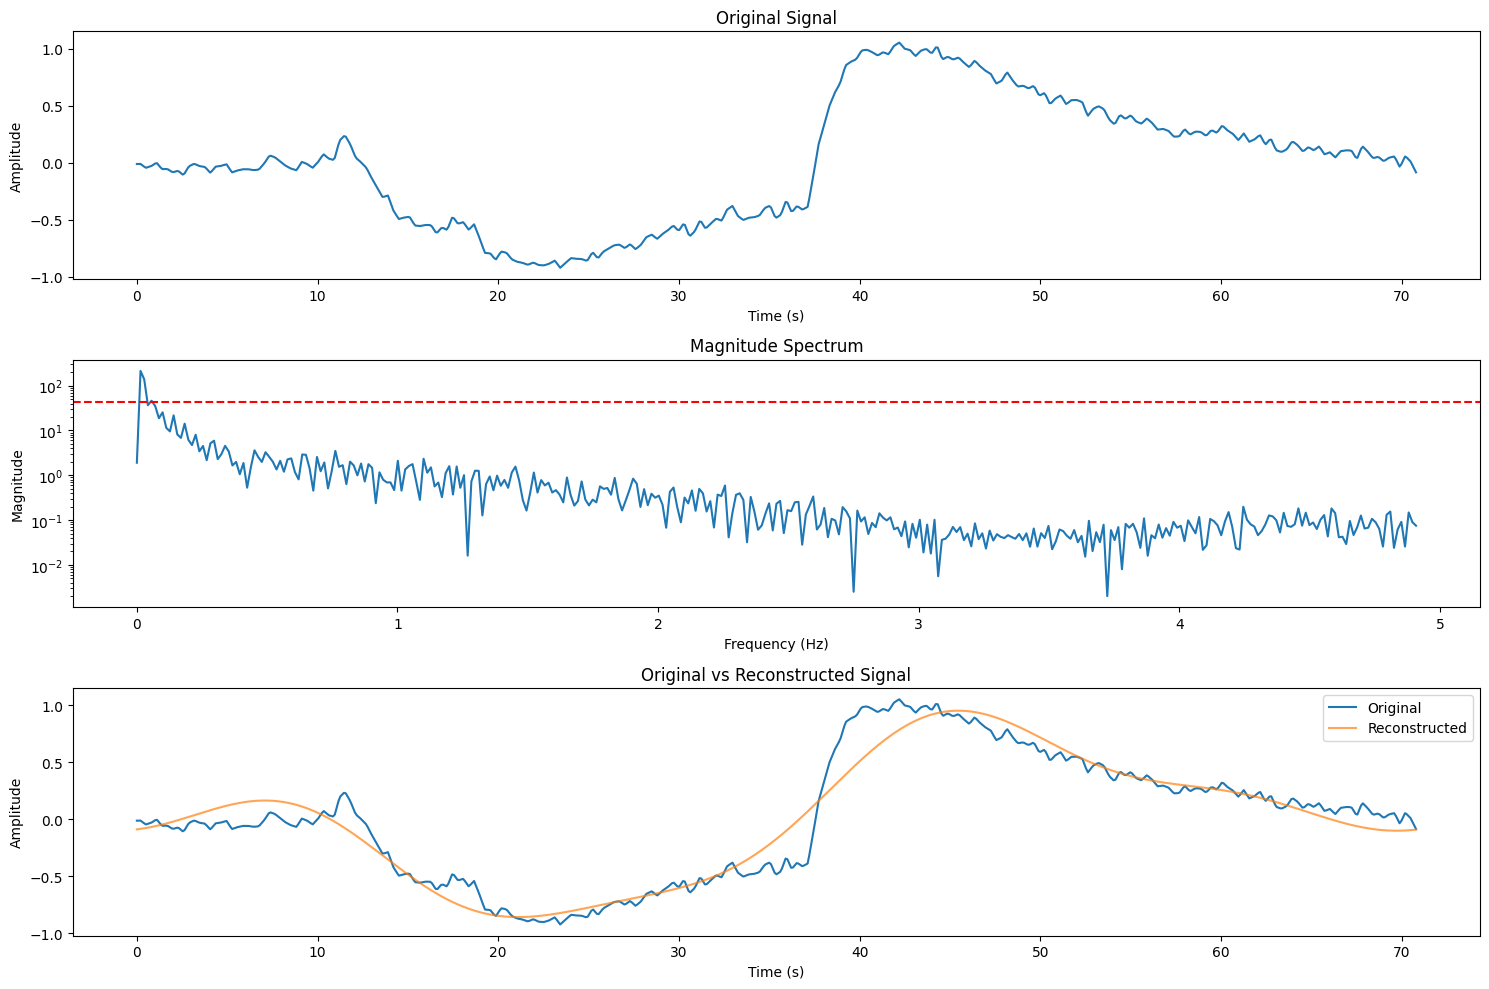

Mean Squared Error: 0.0206740195444126
Significant frequencies: [0.01410466 0.02820931 0.05641863]

Significant Frequencies Analysis:
Frequency (Hz)  Magnitude       % of Max Magnitude  
--------------------------------------------------
0.01            213.39          100.00              
0.03            138.59          64.95               
0.06            46.18           21.64               

Possible fundamental frequency: 0.01 Hz
Possible harmonics:
0.03 Hz (Approximately harmonic 2)
0.06 Hz (Approximately harmonic 4)

Frequency resolution: 0.014 Hz
Signal duration: 70.899 seconds


In [48]:
def analyze_and_reconstruct(signal, sampling_rate, threshold_percent=1):
    # Compute FFT
    fft_result = np.fft.fft(signal)
    frequencies = np.fft.fftfreq(len(signal), 1/sampling_rate)
    
    # Compute magnitude spectrum
    magnitude_spectrum = np.abs(fft_result)
    
    # Identify significant components
    threshold = threshold_percent / 100 * np.max(magnitude_spectrum)
    significant_mask = (magnitude_spectrum > threshold) #& (fft_result > 0)
    
    # Create filtered FFT result
    filtered_fft = fft_result * significant_mask
    
    # Reconstruct using IFFT
    reconstructed_signal = np.fft.ifft(filtered_fft).real
    
    # Plotting
    t = np.arange(len(signal)) / sampling_rate
    plt.figure(figsize=(15, 10))
    
    plt.subplot(3, 1, 1)
    plt.plot(t, signal)
    plt.title('Original Signal')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    
    plt.subplot(3, 1, 2)
    plt.plot(frequencies[:len(frequencies)//2], magnitude_spectrum[:len(frequencies)//2])
    plt.title('Magnitude Spectrum')
    plt.xlabel('Frequency (Hz)')
    plt.axhline(y=threshold, color='r', linestyle='--')
    plt.ylabel('Magnitude')
    plt.yscale('log')
    
    plt.subplot(3, 1, 3)
    plt.plot(t, signal, label='Original')
    plt.plot(t, reconstructed_signal, label='Reconstructed', alpha=0.7)
    plt.title('Original vs Reconstructed Signal')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Compute error
    mse = np.mean((signal - reconstructed_signal)**2)
    print(f"Mean Squared Error: {mse}")
    
    # Print significant frequencies
    sig_freqs = frequencies[significant_mask]
    print("Significant frequencies:", sig_freqs[sig_freqs > 0])



    sig_freqs = frequencies[significant_mask]
    sig_mags = magnitude_spectrum[significant_mask]
    sorted_indices = np.argsort(sig_mags)[::-1]
    sig_freqs_sorted = sig_freqs[sorted_indices]
    sig_mags_sorted = sig_mags[sorted_indices]
    
    print("\nSignificant Frequencies Analysis:")
    print(f"{'Frequency (Hz)':<15} {'Magnitude':<15} {'% of Max Magnitude':<20}")
    print("-" * 50)
    for freq, mag in zip(sig_freqs_sorted, sig_mags_sorted):
        if freq > 0:  # Exclude negative frequencies
            percent_of_max = (mag / np.max(magnitude_spectrum)) * 100
            print(f"{freq:<15.2f} {mag:<15.2f} {percent_of_max:<20.2f}")
    
    # Check for harmonic relationships
    fundamental = sig_freqs_sorted[sig_freqs_sorted > 0][0]  # First positive frequency
    print(f"\nPossible fundamental frequency: {fundamental:.2f} Hz")
    print("Possible harmonics:")
    for freq in sig_freqs_sorted[sig_freqs_sorted > 0][1:]:  # Skip the fundamental
        harmonic_number = round(freq / fundamental)
        if abs(freq - harmonic_number * fundamental) < 0.1:  # Allow for some tolerance
            print(f"{freq:.2f} Hz (Approximately harmonic {harmonic_number})")

    # Calculate and print frequency resolution
    freq_resolution = sampling_rate / len(signal)
    print(f"\nFrequency resolution: {freq_resolution:.3f} Hz")
    print(f"Signal duration: {len(signal)/sampling_rate:.3f} seconds")

# Example usage:
# Replace this with your actual signal data
t = np.arange(0, 699)
signal = terminal

analyze_and_reconstruct(signal, sampling_rate, threshold_percent=20)

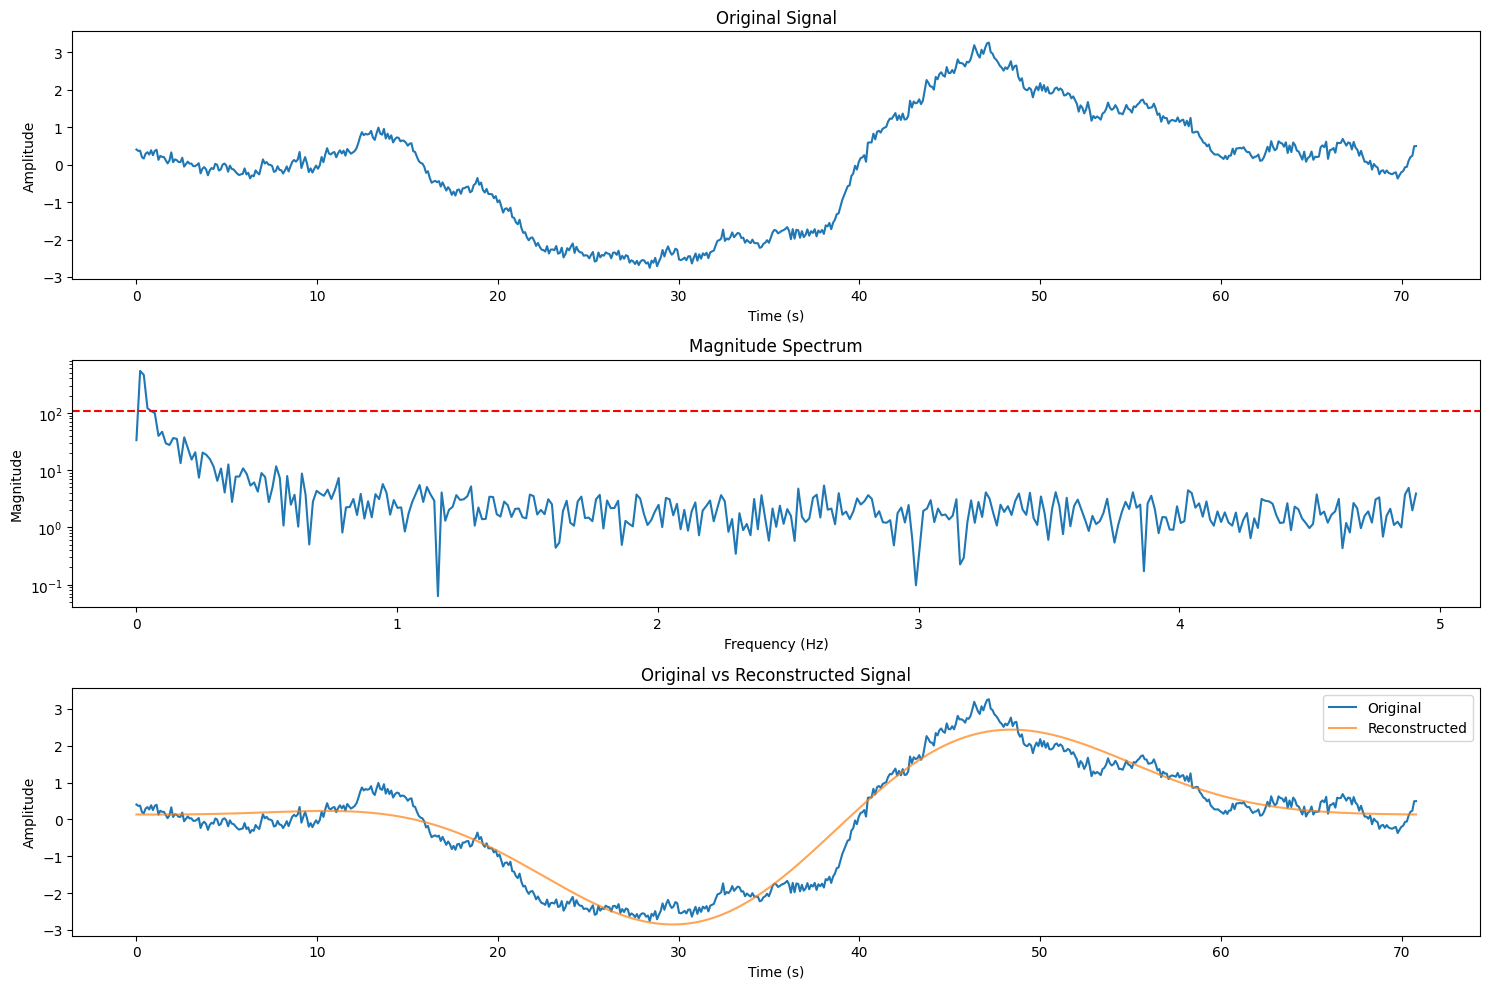

Mean Squared Error: 0.15129549922014363
Significant frequencies: [0.01410466 0.02820931 0.04231397]

Significant Frequencies Analysis:
Frequency (Hz)  Magnitude       % of Max Magnitude  
--------------------------------------------------
0.01            540.47          100.00              
0.03            460.04          85.12               
0.04            120.63          22.32               

Possible fundamental frequency: 0.01 Hz
Possible harmonics:
0.03 Hz (Approximately harmonic 2)
0.04 Hz (Approximately harmonic 3)

Frequency resolution: 0.014 Hz
Signal duration: 70.899 seconds


In [49]:
t = np.arange(0, 699)
signal = nac5

analyze_and_reconstruct(signal, sampling_rate, threshold_percent=20)